In [2]:
# !pip install pyreadstat
# !pip install scikeras tensorflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 617.7/617.7 kB 9.5 MB/s eta 0:00:00a 0:00:01


In [99]:
# pip install --upgrade tensorflow

In [100]:
# import tensorflow as tf
# print("TensorFlow version:", tf.__version__)
# print("GPU available:", tf.config.list_physical_devices('GPU'))


In [3]:
import pyreadstat
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


2025-06-24 01:36:14.631571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750728974.822533      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750728974.879605      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)         # Python hash seed
    random.seed(seed)                                # Python random module
    np.random.seed(seed)                             # NumPy
    tf.random.set_seed(seed)                         # TensorFlow
    tf.keras.utils.set_random_seed(seed)             # For keras randomness
    tf.config.experimental.enable_op_determinism()   # Make ops deterministic

# Call this before training
set_seed(42)


# EDA

In [8]:
df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]
# data = pd.read_spss('/kaggle/input/malnutrition/ch.sav')
# df_ch = pyreadstat.read_sav('C:/Users/dbastola2022/OneDrive - Florida Atlantic University/Academics/Research/Malnutrition/NDHS/Work Progress/Python/malnutrition/MICS/ch.sav')[0]
# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})
df2.head(10)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
3,1.0,9.3,1.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,0
5,0.0,6.9,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
6,1.0,10.5,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,0
7,1.0,10.4,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
10,1.0,8.8,1.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,1.0,1
13,1.0,9.7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
15,1.0,10.3,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
16,1.0,7.7,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1


In [9]:
#Scaling child weight
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

df2.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,-0.617934,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,0.797956,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0


In [105]:
# # Label/one-hot-encoding for Ordinal/nominal features
# le = LabelEncoder()
# df2['mother_education'] = le.fit_transform(df2['mother_education'])
# df2['wealth_index'] = le.fit_transform(df2['wealth_index'])
# df2 = pd.get_dummies(df2, columns = ['province'])
# df = df2.astype(int)
# df.head(10)

# Artificial Neural Network

In [10]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

In [11]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Further split 80% train into 70% train + 10% val
# We want 15% of total data as validation, which is 15 / 80 = 0.1875 of the temp set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, stratify=y_temp, random_state=42)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define model architecture
model_simple = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
])

# Compile model
model_simple.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall']
)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model_simple.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    shuffle=True,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1750729199.890252      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750729199.890940      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


2025-06-24 01:40:01.162006: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5817 - loss: 0.6871 - recall: 0.3976 - val_accuracy: 0.6425 - val_loss: 0.6377 - val_recall: 0.5230
Epoch 2/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6477 - loss: 0.6309 - recall: 0.4902 - val_accuracy: 0.6983 - val_loss: 0.6069 - val_recall: 0.6109
Epoch 3/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6789 - loss: 0.6113 - recall: 0.5379 - val_accuracy: 0.7020 - val_loss: 0.6023 - val_recall: 0.6611
Epoch 4/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6936 - loss: 0.6013 - recall: 0.5270 - val_accuracy: 0.7151 - val_loss: 0.5838 - val_recall: 0.5146
Epoch 5/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6978 - loss: 0.5834 - recall: 0.5076 - val_accuracy: 0.7244 - val_loss: 0.5724 - val_recall: 0.6444
Epoch 6/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7075 - loss: 0.5793 - recall: 0.5461 - val_accuracy: 0.7263 - val_loss: 0.5544 - val_recall: 0.5439
Epoch 7/10

### For better accuracy but has less recall

In [13]:
# # Define model architecture
# model_simple = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dropout(0.2),
#     Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
# ])

# # Compile model
# model_simple.compile(
#     optimizer=Adam(learning_rate=0.005),
#     loss='binary_crossentropy',
#     metrics=['accuracy', 'recall']
# )

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Fit the model
# history = model_simple.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     shuffle=True,
#     epochs=100,
#     batch_size=16,
#     callbacks=[early_stop],
#     verbose=1
# )

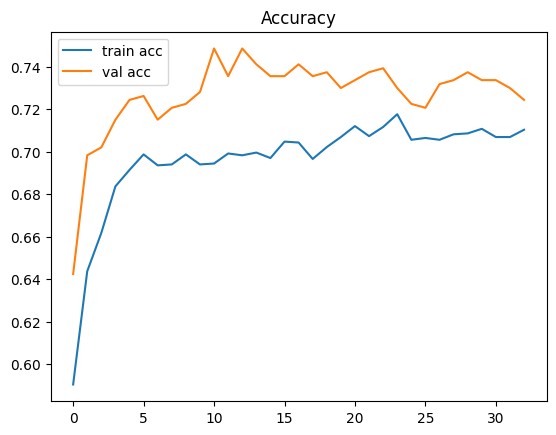

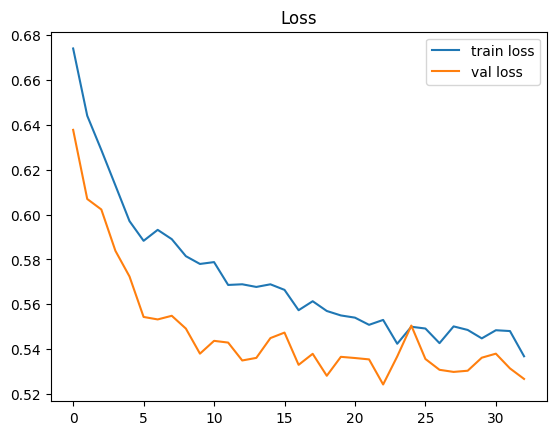

In [14]:
# Accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')

# Loss
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()


In [19]:
y_probs = model_simple.predict(X_test)
y_probs = (y_probs > 0.5).astype("int")

print(classification_report(y_test, y_probs))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.70      0.82      0.76       397
           1       0.72      0.57      0.63       320

    accuracy                           0.71       717
   macro avg       0.71      0.69      0.69       717
weighted avg       0.71      0.71      0.70       717



2025-06-24 01:41:58.034050: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


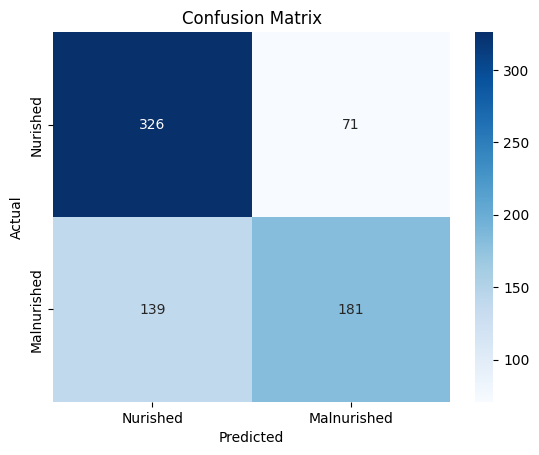

In [16]:
cm = confusion_matrix(y_test, y_probs)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
# Use model.predict() and flatten to 1D
y_probas = model_simple.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average Precision: 0.7626919166806335


2025-06-24 01:42:19.408657: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


2025-06-24 01:42:29.044170: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


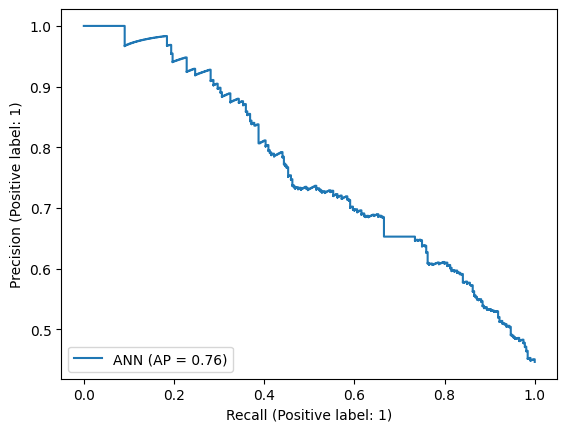

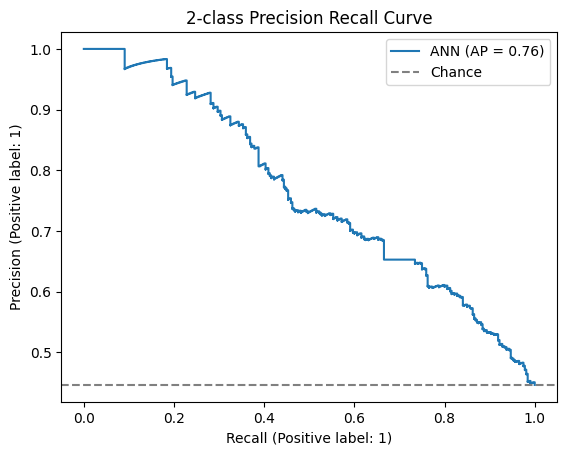

In [21]:
# Get predicted probabilities
y_probas = model_simple.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

---
# Parameter Tunned

In [22]:
from keras_tuner import HyperModel, RandomSearch
from tensorflow.keras import regularizers

# Define a model builder function
def build_model(hp):
    model = Sequential()

    # First dense layer: tune number of neurons and dropout
    model.add(Dense(
        hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))

    # Second dense layer
    model.add(Dense(
        hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.005])),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )

    return model

In [28]:
import keras_tuner as kt

# Define tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_recall',  # Focus on recall
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory='kt_dir',
    project_name='malnutrition_tuning'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run the search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Trial 10 Complete [00h 00m 14s]
val_recall: 0.723849356174469

Best val_recall So Far: 0.7364016771316528
Total elapsed time: 00h 04m 19s


In [29]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")


Best Hyperparameters:
units_1: 128
dropout_1: 0.2
units_2: 64
dropout_2: 0.2
learning_rate: 0.0005


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [30]:
test_loss, test_acc, test_recall = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Recall: {test_recall:.4f}")

2025-06-24 02:13:09.759670: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6411 - loss: 0.6386 - recall: 0.7084  
Test Accuracy: 0.6527
Test Recall: 0.7375


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


2025-06-24 02:13:30.515088: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[[232 165]
 [ 84 236]]


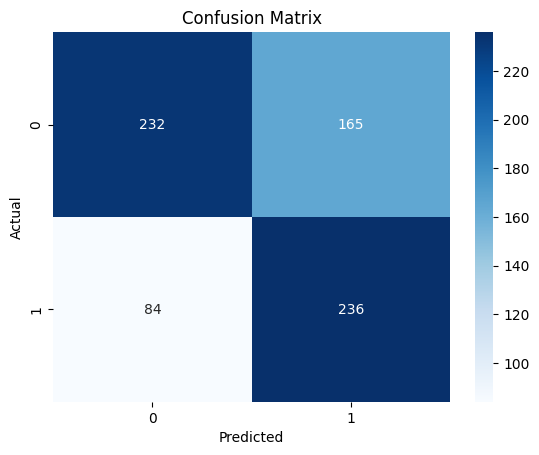

In [31]:
# Predict classes
y_prob = best_model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).reshape(-1)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [32]:
y_probs = best_model.predict(X_test)
y_probs = (y_probs > 0.5).astype("int")

print(classification_report(y_test, y_probs))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.73      0.58      0.65       397
           1       0.59      0.74      0.65       320

    accuracy                           0.65       717
   macro avg       0.66      0.66      0.65       717
weighted avg       0.67      0.65      0.65       717



2025-06-24 02:14:06.056575: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


2025-06-24 02:14:22.550052: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


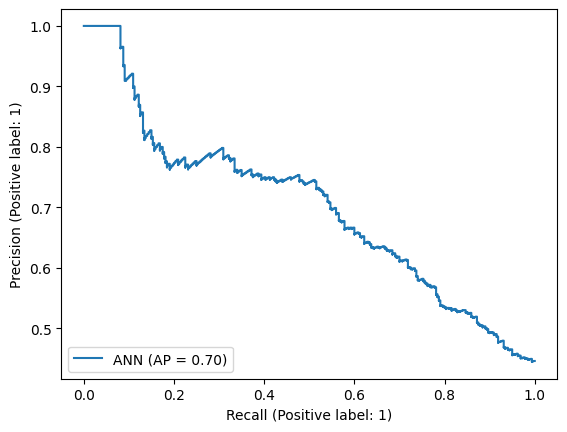

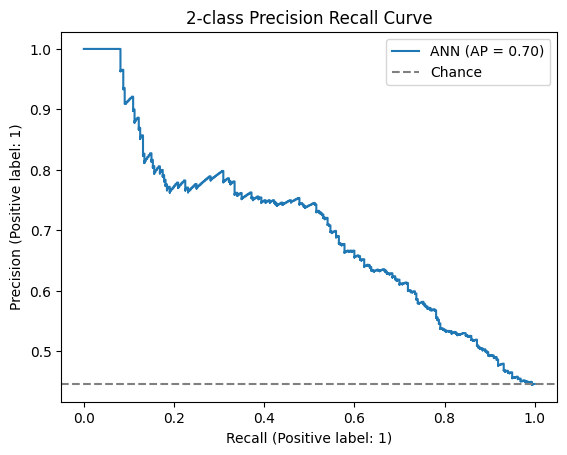

In [33]:
# Get predicted probabilities
y_probas = best_model.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()